### Procesamiento de Lenguaje Natural I
# **Desafío 1**



In [ ]:
%pip install numpy scikit-learn

### Vectorización de texto y modelo de clasificación Naïve Bayes con el dataset 20 newsgroups

In [37]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB, ComplementNB, CategoricalNB
from sklearn.metrics import f1_score

Utilizamos **20newsgroups** por ser un dataset clásico de NLP ya viene incluido y formateado en sklearn

In [2]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Carga de datos

Cargamos los datos (ya separados de forma predeterminada en train y test)

El dataset 20 Newsgroups contiene aproximadamente 18 000 publicaciones de grupos de noticias distribuidas en 20 temas. Está dividido en dos subconjuntos: uno para entrenamiento (train set) y otro para pruebas (test set).

In [4]:
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

## Vectorización

Instanciamos un vectorizador.

Podemos ver diferentes parámetros de instanciación en la documentación de sklearn https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [5]:
tfidfvect = TfidfVectorizer()

En el atributo `data` accedemos al texto

In [6]:
print(newsgroups_train.data[0])

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


Con la interfaz habitual de sklearn podemos ajustar el vectorizador (obtener el vocabulario y calcular el vector IDF) y transformar directamente los datos.

Podemos denominar `X_train` como la matriz documento-término.

In [7]:
X_train = tfidfvect.fit_transform(newsgroups_train.data)

Recordemos que las vectorizaciones por conteos son de tipo sparse, por ello sklearn convenientemente devuelve los vectores de documentos como matrices de tipo sparse.

In [8]:
print(type(X_train))
print(f'shape: {X_train.shape}')
print(f'Cantidad de documentos: {X_train.shape[0]}')
print(f'Tamaño del vocabulario (dimensionalidad de los vectores): {X_train.shape[1]}')

<class 'scipy.sparse._csr.csr_matrix'>
shape: (11314, 101631)
Cantidad de documentos: 11314
Tamaño del vocabulario (dimensionalidad de los vectores): 101631


Una vez ajustado el vectorizador, podemos acceder a atributos como el vocabulario aprendido. Es un diccionario que va de términos a índices.

El índice es la posición en el vector de documento.

In [9]:
tfidfvect.vocabulary_['car']

25775

Probamos con una palbra que no está en el documento.

In [10]:
tfidfvect.vocabulary_['cocoliso']

KeyError: 'cocoliso'

Es muy útil tener el diccionario opuesto que va de índices a términos

In [11]:
idx2word = {v: k for k,v in tfidfvect.vocabulary_.items()}

En `y_train` guardamos los targets que son enteros

In [12]:
y_train = newsgroups_train.target
y_train[:10]

array([ 7,  4,  4,  1, 14, 16, 13,  3,  2,  4])

Hay 20 clases correspondientes a los 20 grupos de noticias

In [13]:
print(f'clases {np.unique(newsgroups_test.target)}')
newsgroups_test.target_names

clases [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

## Similaridad de documentos

Veamos similaridad de documentos. Tomemos algún documento

In [14]:
idx = 4811
print(newsgroups_train.data[idx])

THE WHITE HOUSE

                  Office of the Press Secretary
                   (Pittsburgh, Pennslyvania)
______________________________________________________________
For Immediate Release                         April 17, 1993     

             
                  RADIO ADDRESS TO THE NATION 
                        BY THE PRESIDENT
             
                Pittsburgh International Airport
                    Pittsburgh, Pennsylvania
             
             
10:06 A.M. EDT
             
             
             THE PRESIDENT:  Good morning.  My voice is coming to
you this morning through the facilities of the oldest radio
station in America, KDKA in Pittsburgh.  I'm visiting the city to
meet personally with citizens here to discuss my plans for jobs,
health care and the economy.  But I wanted first to do my weekly
broadcast with the American people. 
             
             I'm told this station first broadcast in 1920 when
it reported that year's presidential elec

Medimos la similaridad coseno con todos los documentos de train

In [15]:
cossim = cosine_similarity(X_train[idx], X_train)[0]

Podemos ver los valores de similaridad ordenados de mayor a menor

In [16]:
np.sort(cossim)[::-1]

array([1.        , 0.70930477, 0.67474953, ..., 0.        , 0.        ,
       0.        ], shape=(11314,))

Después vemos a qué documentos corresponden

In [17]:
np.argsort(cossim)[::-1]

array([4811, 6635, 4253, ..., 9019, 9016, 8748], shape=(11314,))

Obtenemos los 5 documentos más similares:

In [18]:
mostsim = np.argsort(cossim)[::-1][1:6]
print(mostsim)

[6635 4253 3596 4271 3746]


El documento original pertenece a la clase:

In [19]:
newsgroups_train.target_names[y_train[idx]]

'talk.politics.misc'

Revisamos las clases de los 5 más similares:

In [20]:
for i in mostsim:
  print(newsgroups_train.target_names[y_train[i]])

talk.politics.misc
talk.politics.misc
talk.politics.misc
talk.politics.misc
talk.politics.misc


### Modelo de clasificación Naïve Bayes

Instanciamos el modelo de clasificación Naive Bayes y lo entrenamos con sklearn

In [21]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Ya tenemos nuestro vectorizador ya ajustado en train, vectorizamos los textos
del conjunto de test.

In [22]:
X_test = tfidfvect.transform(newsgroups_test.data)
y_test = newsgroups_test.target
y_pred =  clf.predict(X_test)

El F1-score es una métrica adecuada para evaluar el desempeño de modelos de clasificación, especialmente cuando existe desbalance entre clases.

* El promediado macro calcula el promedio del F1-score de cada clase, otorgando el mismo peso a todas las clases.
* El promediado micro calcula las métricas de forma global considerando todas las predicciones; en problemas de clasificación multiclase suele ser equivalente a la accuracy, por lo que no es la mejor métrica cuando el dataset está desbalanceado.

In [ ]:
print(f1_score(y_test, y_pred, average='macro'))

0.637426504468489


: 

---

## **Consigna del Desafío 1**
**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado.**



**1. Vectorizar documentos**
* Tomar 5 documentos al azar y medir similaridad con el resto de los documentos.
Estudiar los 5 documentos más similares de cada uno analizar si tiene sentido
la similaridad según el contenido del texto y la etiqueta de clasificación.

**2. Construir un modelo de clasificación por prototipos (tipo zero-shot).**
* Clasificar los documentos de un conjunto de test comparando cada uno con todos los de entrenamiento y asignar la clase al label del documento del conjunto de entrenamiento con mayor similaridad.

**3. Entrenar modelos de clasificación Naïve Bayes para maximizar el desempeño de clasificación**

* F1-Score Macro en el conjunto de datos de test. Considerar cambiar parámetros
de instanciación del vectorizador y los modelos y probar modelos de Naïve Bayes Multinomial y ComplementNB.

**NO cambiar el hiperparámetro ngram_range de los vectorizadores**.

**4. Transponer la matriz documento-término.**
* De esa manera se obtiene una matriz término-documento que puede ser interpretada como una colección de vectorización de palabras.
* Estudiar ahora similaridad entre palabras tomando 5 palabras y estudiando sus 5 más similares.

**Elegir las palabras MANUALMENTE para evitar la aparición de términos poco interpretables**.


### 1. Vectorizar documentos
Tomar 5 documentos al azar y medir similaridad con el resto de los documentos.
Estudiar los 5 documentos más similares de cada uno analizar si tiene sentido
la similaridad según el contenido del texto y la etiqueta de clasificación.


In [24]:
from sklearn.feature_extraction.text import CountVectorizer
import random

random.seed(42)
rand_idxs = [random.randint(0,X_train.shape[0]) for _ in range(5)]
# count_vectorizer = CountVectorizer()
# X_train_count = count_vectorizer.fit_transform(newsgroups_train.data)
# idx2word_count = {v: k for k,v in count_vectorizer.vocabulary_.items()}


for idx in rand_idxs:
    print("-------------------")
    print(f"Documento N {idx}")
    texto = newsgroups_train.data[idx]
    clase = newsgroups_train.target[idx]
    vector = X_train[idx]
    vector_array = vector.toarray()[0]
    docs_en_clase = (newsgroups_train.target == clase).sum()
    print(f"Clase del documento: {newsgroups_test.target_names[clase]} ({docs_en_clase} docs. en total)")
    
    print(f"10 palabras más frecuentes en el documento según TF-IDF:")
    most_common_terms_idx = np.argsort(vector_array)[::-1][0:10]
    most_common_terms = [idx2word[term_idx] for term_idx in most_common_terms_idx]
    # most_common_terms_reps = [count_vector_array[count_vectorizer.vocabulary_[term]] for term in most_common_terms]
    # print(", ".join(f"{most_common_terms[i]} ({most_common_terms_reps[i]} reps)" for i in range(len(most_common_terms))))yypk
    print("   " + ", ".join(f"{term}" for term in most_common_terms))


    # obtengamos la similitud coseno con todos los docs de train
    cossim = cosine_similarity(vector, X_train)[0]
    most_sim = np.argsort(cossim)[::-1][1:6] # el 0 no va xq seria el mismo doc
    print(f"Documentos más similares:")
    for idx_sim in most_sim:
        clase_i_sim = newsgroups_test.target_names[newsgroups_train.target[idx_sim]]
        print(f"   {idx_sim}")
        print(f"      clase: {clase_i_sim}")
        vector_sim = X_train[idx_sim].toarray()[0]
        most_common_terms_sim = [idx2word[term_idx] for term_idx in np.argsort(vector_sim)[::-1][0:10]]
        print("      palabras más frecuentes: "+", ".join(f"{term}" for term in most_common_terms_sim))


    
    print("-------------------")

-------------------
Documento N 10476
Clase del documento: rec.sport.hockey (600 docs. en total)
10 palabras más frecuentes en el documento según TF-IDF:
   series, coverage, canada, watch, games, swamped, news, precedence, televised, nationally
Documentos más similares:
   5064
      clase: rec.sport.hockey
      palabras más frecuentes: detroit, chicago, games, exciting, classic, mon, playoff, boston, fan, realize
   9623
      clase: talk.politics.mideast
      palabras más frecuentes: the, and, they, were, was, that, he, to, you, it
   10575
      clase: sci.crypt
      palabras más frecuentes: the, to, it, not, is, rights, this, be, government, clipper
   10836
      clase: alt.atheism
      palabras más frecuentes: the, of, is, god, that, in, to, atheists, universe, it
   2350
      clase: sci.crypt
      palabras más frecuentes: the, internet, anonymity, anonymous, and, privacy, of, is, to, are
-------------------
-------------------
Documento N 1824
Clase del documento: comp.sy

Se observa que en el caso de algunos documentos, los documentos más similares por similitud coseno no son de categorías similares.
En categorías con vocabulario muy específico como el de `comp.sys.max.hardware` o `comp.graphics` se tiene mejores coincidencias que en la característica de `rec.sport.hockey`, la cual tiene vocabulario más general, fácilmente confundible con el vocabulario de otra clase.
En el caso del documento perteneciente a `rec.autos`, se tiene confunsión con la clase `rec.motorcycles`, la cual es bastante cercana.

### 2. Construir un modelo de clasificación por prototipos (tipo zero-shot).
Clasificar los documentos de un conjunto de test comparando cada uno con todos los de entrenamiento y asignar la clase al label del documento del conjunto de entrenamiento con mayor similaridad.

Defino una función que permite a 1 documento buscar aquel con mayor similitud coseno y luego devolver el índice de la clase del mismo.

In [25]:
def zero_shot_model(tgt_text, train_set, vectorizer, train_tgts, tgt_dict):
    tgt_vectorized = vectorizer.transform([tgt_text])
    cos_sim = cosine_similarity(tgt_vectorized, train_set)[0]
    most_sim = np.argmax(cos_sim)
    most_sim_class_idx = train_tgts[most_sim]

    return most_sim_class_idx

Genero la predicción para todo el set de test y calculo el F1-score y la precisión.

In [26]:
y_pred_zero_shot = [zero_shot_model(test_data, X_train, tfidfvect, newsgroups_train.target, newsgroups_train.target_names) for test_data in newsgroups_test.data]

In [73]:
from sklearn.metrics import accuracy_score

print("Modelo zero-shot")
print(f"F1-score: {f1_score(y_test, y_pred_zero_shot, average='macro'):.3f}")
print(f"Precisión: {accuracy_score(y_test, y_pred_zero_shot):.3f}")

Modelo zero-shot
F1-score: 0.505
Precisión: 0.509


### 3. Entrenar modelos de clasificación Naïve Bayes para maximizar el desempeño de clasificación
F1-Score Macro en el conjunto de datos de test. Considerar cambiar parámetros de instanciación del vectorizador y los modelos y probar modelos de Naïve Bayes Multinomial y ComplementNB.

Defino una función que me permita fácilmente vectorizar con un dado vectorizador, y luego predecir con un modelo Naive Bayes:

In [42]:
def test_vectorizer_and_model(vectorizer_model, predictor_model, train_data, test_data, train_tgt, test_tgt, alpha=1.0):
    vectorizer = vectorizer_model() 

    X_train = vectorizer.fit_transform(train_data)
    X_test = vectorizer.transform(test_data)
    y_train = train_tgt
    y_test = test_tgt

    predictor = predictor_model(alpha=alpha)
    predictor.fit(X_train, y_train)

    y_pred = predictor.predict(X_test)

    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)

    # print(f"F1-score: {f1:.3f}")
    # print(f"Accuracy score: {acc:.3f}")

    return y_pred, f1, acc


Evaluo los vectorizadores TF-IDF y contador, y los predictores NB Multinomial y NB Complemento. A estos últimos les varío su argumento `alpha` entre 1E-8, 0.1, 0.33, 0.66 y 1 (valor por defecto).

In [74]:
vectorizers = {
    'TFIDF': TfidfVectorizer,
    'Count Vectorizer': CountVectorizer
}
predictors = {
    'Multinomial NB': MultinomialNB,
    'Complement NB': ComplementNB,
}

models = {
    'vectorizer': [],
    'predictor': [],
    'alpha': [],
    'y_pred': [],
    'f1 score': [],
    'accuracy': []
}

for vectorizer in vectorizers.keys():
    for predictor in predictors.keys():
        for alpha in [1e-8, 0.1, 0.33, 0.66, 1]:
            y_pred, f1score, acc_score = test_vectorizer_and_model(
                vectorizers[vectorizer],
                predictors[predictor],
                newsgroups_train.data, newsgroups_test.data, newsgroups_train.target, newsgroups_test.target,
                alpha=alpha
            )
            models['vectorizer'].append(vectorizer)
            models['predictor'].append(predictor)
            models['alpha'].append(alpha)
            models['y_pred'].append(y_pred)
            models['f1 score'].append(f1score)
            models['accuracy'].append(acc_score)



A continuación podemos ver graficados el F1-score y la precisión de todas las combinaciones evaluadas. Podemos ver que el modelo claramente superior es el que combina TFIDF y NB Complemento, con un valor alpha de 0.33.

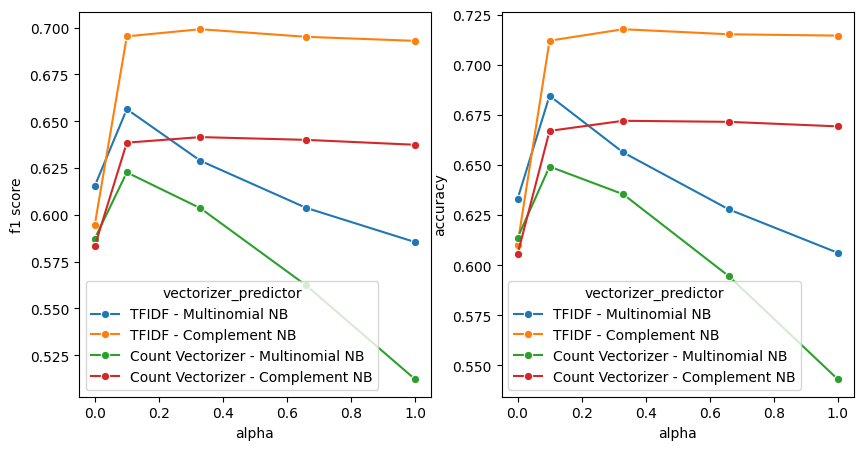

In [75]:
models_df = pd.DataFrame.from_dict(models)
models_df['vectorizer_predictor'] = models_df['vectorizer'] + ' - ' + models_df['predictor']

# sns.barplot(data=models_df, x='alpha', y='f1 score', hue='vectorizer_predictor')
fig, axs = plt.subplots(1,2,figsize=(10,5))
sns.lineplot(data=models_df, x='alpha', y='f1 score', hue='vectorizer_predictor', marker='o', ax=axs[0])
sns.lineplot(data=models_df, x='alpha', y='accuracy', hue='vectorizer_predictor', marker='o', ax=axs[1])
plt.show()

### 4. Transponer la matriz documento-término.
De esa manera se obtiene una matriz término-documento que puede ser interpretada como una colección de vectorización de palabras.

Estudiar ahora similaridad entre palabras tomando 5 palabras y estudiando sus 5 más similares.

**Elegir las palabras MANUALMENTE para evitar la aparición de términos poco interpretables**.


Aplico la traspuesta a la matriz documento-término y luego busco las 6 palabras más similares a las palabras 'salzburg', 'pipeline', 'altruistic', 'intercontinental' y 'blanket'.

Observamos que:
- `salzburg` no tiene como palabra más similar a si misma, y si analizamos el valor de similitud coseno, se tienen al menos 6 palabras con valor exactamente igual a 1. Si analizamos en detalle, esto sucede por esta palabra sólo aparece en 1 documento (el índice 1686), y se tienen otras palabras que sólo aparecen en el mismo documento. Esto hace que al calcular la similitud coseno entre estos vectores, tengan sólo valor distinto de cero en la posición 1686, y como la similitud coseno se basa en la dirección del vector, el ángulo entre ellos es 0, dando similitud 1.
- En todo el resto de palabras, la única palabra con similitud 1 es la palabra misma.
- `intercontinental` y `altruistic` tienen algunas coincidencias de significado similar.

In [83]:
term_docs = X_train.T
print(np.linalg.norm(term_docs[80358].toarray()))

term_idxs = [80358, 71520, 18140, 50490, 23121]
print([idx2word[i] for i in term_idxs])

for term_i in term_idxs:
    cossim = cosine_similarity(term_docs[term_i], term_docs)[0]
    most_sim_terms = np.argsort(cossim)[::-1][0:6]
    # most_sim_term = np.argmax(cossim)
    print(f"{idx2word[term_i]} -> " + ", ".join([f'{i} {idx2word[i]} ({cossim[i]:.2f})' for i in most_sim_terms]))

0.06948259697573497
['salzburg', 'pipeline', 'altruistic', 'intercontinental', 'blanket']
salzburg -> 19424 archivist (1.00), 38159 euphemism (1.00), 66894 nuremberg (1.00), 20463 ausrottung (1.00), 80358 salzburg (1.00), 86503 supervisory (1.00)
pipeline -> 71520 pipeline (1.00), 32672 delicious (0.99), 90772 twit (0.99), 94439 vip (0.89), 17030 advert (0.56), 92654 upfront (0.54)
altruistic -> 18140 altruistic (1.00), 15689 _which (0.88), 38075 ethica (0.88), 49682 indeterminism (0.88), 86579 sure_ (0.88), 15066 _for (0.88)
intercontinental -> 50490 intercontinental (1.00), 30121 countires (0.84), 45337 hafez (0.84), 38898 extradite (0.84), 2203 11a (0.84), 28666 communites (0.84)
blanket -> 23121 blanket (1.00), 80186 saddam (0.42), 47881 hussein (0.39), 61978 mirth (0.36), 70266 pax (0.34), 61843 mindedness (0.33)


Análisis de palabras `salzburg` y `archivist`:

In [99]:
idx1 = 80358
vec1 = term_docs[idx1].toarray().reshape(-1)
idx2 = 19424
vec2 = term_docs[idx2].toarray().reshape(-1)

def angle_between(v1, v2):
    # Normalize vectors
    v1_u = v1 / np.linalg.norm(v1)
    v2_u = v2 / np.linalg.norm(v2)
    
    # Clip to avoid numerical errors (e.g., values like 1.00000002)
    # dot_product = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
    dot_product = np.dot(v1_u, v2_u)
    
    # Return angle in radians
    return np.arccos(dot_product)

print(f"Ángulo entre vectores: {angle_between(vec1, vec2)}")
print(f"Lista de docs en los que aparece {idx2word[idx1]}: {np.nonzero(vec1)[0].tolist()}")
print(f"Lista de docs en los que aparece {idx2word[idx2]}: {np.nonzero(vec2)[0].tolist()}")

Ángulo entre vectores: 0.0
Lista de docs en los que aparece salzburg: [1686]
Lista de docs en los que aparece archivist: [1686]
